# LockBench — ML surrogate for PVT-robust PLL design

This notebook trains and validates the machine-learning surrogate that powers LockBench's
instant *inverse design*, and shows how it relates to the physics engine.

**Honesty framing (read this first).** The surrogate's training rows are generated by the
*linear PLL model* — fast and exact **for that model**. The **real datasheet device library
is the grounding and validation**, not the ML training set. So the ML here is an
*accelerator* over a physics model, not a data-driven claim about silicon. That distinction
is deliberate and is what keeps the tool defensible.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # repo root, so `controlbench` imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from controlbench.pll import (
    load_devices, get_device, divider_for_output,
    design_pll, evaluate, CornerSpec, PLLSpec, sweep_corners, robust_evaluate,
)
from controlbench.pll import ml

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.color": "#e6edf5"})
pd.set_option("display.float_format", lambda x: f"{x:.4g}")

## 1 · The real device library
Every design is anchored on a shipping synthesizer IC.

In [2]:
rows = [d.summary() for d in load_devices()]
pd.DataFrame(rows)[["name","vendor","vco_min_hz","vco_max_hz","kvco_mhz_per_v",
                    "icp_default_ma","pfd_max_hz"]]

,name,vendor,vco_min_hz,vco_max_hz,kvco_mhz_per_v,icp_default_ma,pfd_max_hz
0,ADF4351,Analog Devices,2.2e+09,4.4e+09,40,2.5,3.2e+07
1,LMX2594,Texas Instruments,7.5e+09,1.5e+10,20,6.25,4e+08
2,ADF5355,Analog Devices,3.4e+09,6.8e+09,55,0.94,1.25e+08


## 2 · The design engine on a real chip
Design an ADF4351 loop (2.4 GHz VCO, 10 MHz phase-detector) for a 20 kHz bandwidth and
50° phase margin, then **measure** what we actually got back from the transfer function.

In [3]:
dev = get_device("adf4351")
n = divider_for_output(dev, f_out_hz=2.4e9, f_pfd_hz=10e6)
pll = design_pll(dev, n=n, fc_hz=20e3, phase_margin_deg=50.0)
lf, m = pll.loop_filter, evaluate(pll)
print(f"N = {n:.0f}   Icp = {pll.icp_a*1e3:.2f} mA   Kvco = {dev.kvco_hz_per_v/1e6:.0f} MHz/V")
print(f"loop filter: R = {lf.r:.1f} ohm, C_main = {lf.c_main*1e9:.2f} nF, "
      f"C_shunt = {lf.c_shunt*1e9:.2f} nF")
print(f"zero = {lf.zero_hz/1e3:.2f} kHz, 3rd pole = {lf.pole3_hz/1e3:.1f} kHz")
print(f"MEASURED: bandwidth = {m.loop_bandwidth_hz/1e3:.2f} kHz, PM = {m.phase_margin_deg:.1f} deg, "
      f"lock = {m.lock_time_s*1e6:.1f} us, jitter peaking = {m.jitter_peaking_db:.2f} dB")

N = 240   Icp = 2.50 mA   Kvco = 40 MHz/V
loop filter: R = 347.6 ohm, C_main = 62.89 nF, C_shunt = 9.60 nF
zero = 7.28 kHz, 3rd pole = 54.9 kHz
MEASURED: bandwidth = 20.00 kHz, PM = 50.0 deg, lock = 56.9 us, jitter peaking = 2.59 dB


## 3 · PVT robustness
The loop filter is fixed, but Kvco (±30%) and Icp (±10%) drift across process/voltage/
temperature. A design is only trustworthy if it holds spec at **every** corner.

In [4]:
results = sweep_corners(pll, CornerSpec(kvco_tol=0.30, icp_tol=0.10))
pd.DataFrame([{
    "corner": r.corner.name, "Kvco x": r.corner.kvco_mult, "Icp x": r.corner.icp_mult,
    "PM (deg)": r.metrics.phase_margin_deg, "lock (us)": r.metrics.lock_time_s*1e6,
    "peak (dB)": r.metrics.jitter_peaking_db,
} for r in results])

,corner,Kvco x,Icp x,PM (deg),lock (us),peak (dB)
0,TT (nominal),1,1,50,56.86,2.59
1,"kvco-, icp-",0.7,0.9,48.1,102.8,3.223
2,"kvco-, icp+",0.7,1.1,49.38,64.11,2.916
3,"kvco+, icp-",1.3,0.9,49.77,53.79,2.442
4,"kvco+, icp+",1.3,1.1,48.84,52.38,2.328


## 4 · The surrogate
`data/pll_dataset.csv` holds model-labelled designs sampled across the device library. The
features are the *design point*; the labels are the *worst-case-across-PVT* metrics.

In [5]:
df = pd.read_csv(Path.cwd().parent / "data" / "pll_dataset.csv")
print("rows:", len(df))
print("features:", ml.FEATURES)
print("labels  :", ml.LABELS)
df.head()

rows: 900
features: ['log10_fc_hz', 'pm_target_deg', 'log10_icp_a', 'log10_n', 'log10_kvco_hz']
labels  : ['worst_phase_margin_deg', 'log10_worst_lock_time_s', 'worst_jitter_peaking_db']


,log10_fc_hz,pm_target_deg,log10_icp_a,log10_n,log10_kvco_hz,worst_phase_margin_deg,log10_worst_lock_time_s,worst_jitter_peaking_db
0,5.982,60.33,-2.463,1.833,7.74,58.33,-5.722,2.236
1,7.316,63.38,-1.903,1.675,7.301,61.42,-7.019,1.992
2,5.119,58.24,-2.359,2.8,7.602,56.23,-4.883,2.414
3,6.738,50.57,-3.027,1.673,7.74,48.65,-6.428,3.161
4,7.017,55.38,-3.028,2.02,7.301,53.39,-6.812,2.673


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df[ml.FEATURES].values
Y = df[ml.LABELS].values
Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.25, random_state=1)
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=0, n_jobs=-1)
rf.fit(Xtr, Ytr)
r2 = r2_score(Yte, rf.predict(Xte), multioutput="raw_values")
for lbl, s in zip(ml.LABELS, r2):
    print(f"  R^2  {lbl:32s} {s:6.3f}")

  R^2  worst_phase_margin_deg            1.000
  R^2  log10_worst_lock_time_s           0.900
  R^2  worst_jitter_peaking_db           1.000


### Feature importance
Which design knobs the surrogate leans on for each prediction.

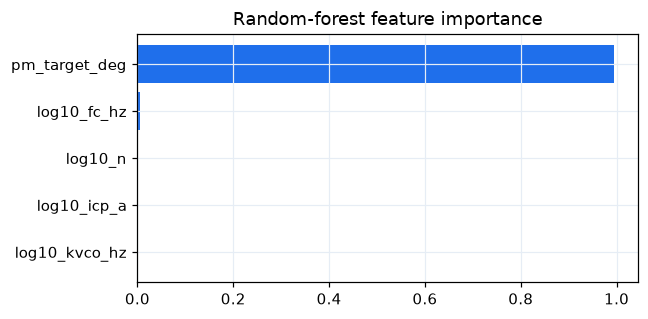

In [7]:
imp = rf.feature_importances_
order = np.argsort(imp)
plt.figure(figsize=(6, 3))
plt.barh([ml.FEATURES[i] for i in order], imp[order], color="#1f6feb")
plt.title("Random-forest feature importance"); plt.tight_layout(); plt.show()

### ML vs physics model — held-out parity
Points on the diagonal mean the surrogate reproduces the physics model. Worst-case phase
margin is near-deterministic; worst-case lock time is the genuinely hard target.

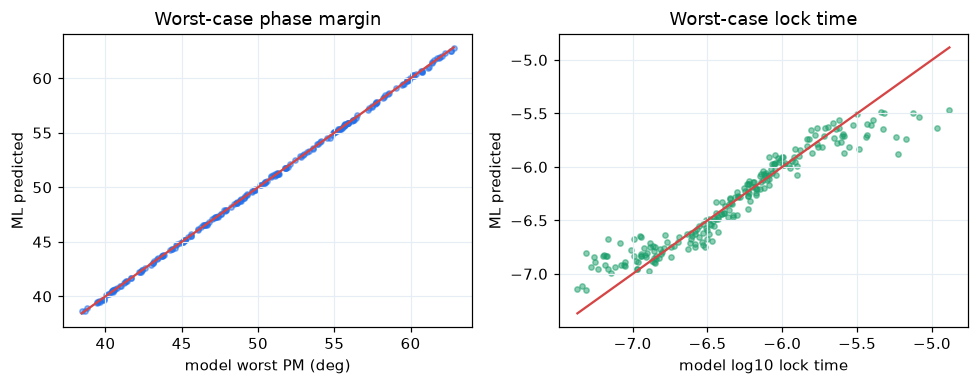

In [8]:
P = rf.predict(Xte)
fig, (a, b) = plt.subplots(1, 2, figsize=(9, 3.6))
a.scatter(Yte[:,0], P[:,0], s=12, alpha=0.5, color="#1f6feb")
a.plot([Yte[:,0].min(), Yte[:,0].max()]*1, [Yte[:,0].min(), Yte[:,0].max()], color="#d64545")
a.set_xlabel("model worst PM (deg)"); a.set_ylabel("ML predicted"); a.set_title("Worst-case phase margin")
b.scatter(Yte[:,1], P[:,1], s=12, alpha=0.5, color="#1a9e6a")
b.plot([Yte[:,1].min(), Yte[:,1].max()], [Yte[:,1].min(), Yte[:,1].max()], color="#d64545")
b.set_xlabel("model log10 lock time"); b.set_ylabel("ML predicted"); b.set_title("Worst-case lock time")
plt.tight_layout(); plt.show()

## 5 · Inverse design
The real payoff: give the surrogate a *spec*, and it recommends a design point in
milliseconds. We then **verify that recommendation against the physics model**.

In [9]:
bundle = ml.load_surrogate(Path.cwd().parent / "models" / "pll_surrogate.joblib")
spec = PLLSpec(min_phase_margin_deg=48.0, max_jitter_peaking_db=3.0)
rec = ml.recommend_design(bundle, dev, n, spec, f_pfd_hz=10e6)
print("ML recommends:", f"fc = {rec.fc_hz/1e3:.1f} kHz, PM = {rec.phase_margin_deg:.0f} deg, "
      f"Icp = {rec.icp_a*1e3:.2f} mA")
print("ML predicts  :", {k: round(v, 3) for k, v in rec.predicted.items()})

check = robust_evaluate(design_pll(dev, n=n, fc_hz=rec.fc_hz,
                                   phase_margin_deg=rec.phase_margin_deg, icp_a=rec.icp_a),
                        spec, CornerSpec(kvco_tol=0.30, icp_tol=0.10))
print("physics model:", f"worst PM = {check.worst['min_phase_margin_deg']:.1f} deg, "
      f"worst lock = {check.worst['max_lock_time_s']*1e6:.1f} us, "
      f"worst peak = {check.worst['max_jitter_peaking_db']:.2f} dB, passes = {check.passes}")

ML recommends: fc = 1250.0 kHz, PM = 53 deg, Icp = 3.44 mA
ML predicts  : {'worst_phase_margin_deg': 51.058, 'worst_lock_time_s': 0.0, 'worst_jitter_peaking_db': 2.904}


physics model: worst PM = 51.0 deg, worst lock = 1.2 us, worst peak = 2.91 dB, passes = True


## Takeaways

- The surrogate reproduces the physics model closely (worst-case PM essentially exactly;
  lock time with some spread), so it is a safe *accelerator* for design-space search.
- Inverse design turns a spec into a starting design instantly; LockBench always lets you
  **verify against the model** before trusting it.
- **Scope/limitation:** this validates the surrogate against the *linear PLL model*, not
  against SPICE or silicon. Extending the ground truth to a behavioural/transistor-level
  model is the natural next step.